ResNETBlock(
  (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)
torch.Size([2, 32, 16, 16])


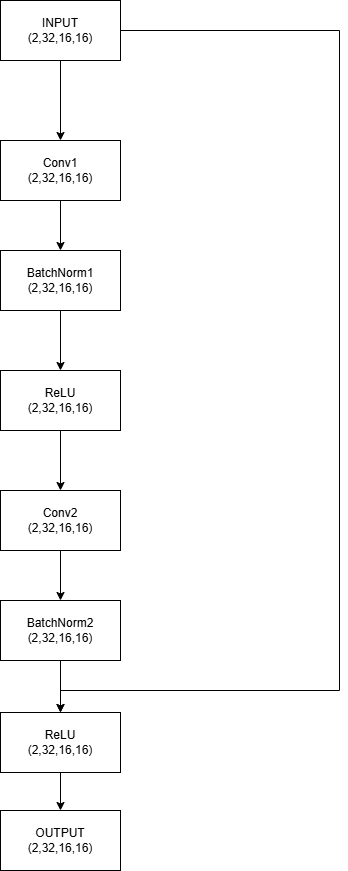

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
class ResNETBlock(nn.Module):
    def __init__(self,ch=32):
        super().__init__()
        self.conv1 = nn.Conv2d(ch,ch,3,padding=1)
        self.bn1 = nn.BatchNorm2d(ch)
        self.conv2 = nn.Conv2d(ch,ch,3,padding=1)
        self.bn2 = nn.BatchNorm2d(ch)
    def forward(self,x):
        h = F.relu(self.bn1(self.conv1(x)))
        h = self.bn2(self.conv2(h)) 
        return F.relu(h + x)
model = ResNETBlock()
model.eval()
print(model)
with torch.no_grad():
    out = model(torch.randn(2,32,16,16))
    print(out.shape)  
from PIL import Image
import IPython.display as display
img = Image.open('ResNET.png')
display.display(img)            

UNET(
  (enc1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
  )
  (enc2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
  )
  (enc3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
  )
  (bot): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
  )
  (up3): ConvTranspose2d(256, 128, kernel_size=(2, 2), stride=(2, 2))
  (dec3): Sequential(
    (0): Conv2d(256, 128, kernel_size=(3, 3), stride=(1, 1), padd

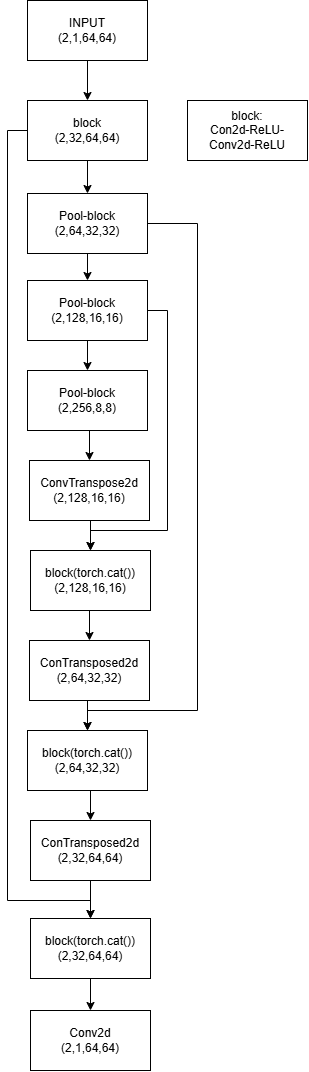

In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F
class UNET(nn.Module):
    def __init__(self,in_ch=1,base=32):
        super().__init__()
        self.enc1 = self._block(in_ch,base)
        self.enc2 = self._block(base,base * 2)
        self.enc3 = self._block(base * 2,base * 4)
        self.bot = self._block(base * 4,base * 8)
        self.up3 = nn.ConvTranspose2d(base*8,base*4,2,stride=2)
        self.dec3 = self._block(base*8,base*4)
        self.up2 = nn.ConvTranspose2d(base*4,base*2,2,stride=2)
        self.dec2 = self._block(base*4,base*2)
        self.up1 = nn.ConvTranspose2d(base*2,base,2,stride=2)
        self.dec1 = self._block(base*2,base)
        self.out = self._block(base,in_ch)
        self.pool = nn.MaxPool2d(2)

    def _block(self,ic,oc):
        return nn.Sequential(
            nn.Conv2d(ic,oc,3,padding=1),nn.ReLU(),
            nn.Conv2d(oc,oc,3,padding=1),nn.ReLU()
        )
    def forward(self,x):
        print('x',x.shape)
        e1 = self.enc1(x)
        print('e1',e1.shape)
        e2 = self.enc2(self.pool(e1))
        print('e2',e2.shape)
        e3 = self.enc3(self.pool(e2))
        print('e3',e3.shape)
        b = self.bot(self.pool(e3))
        print('b',b.shape)
        d3 = self.dec3(torch.cat([self.up3(b),e3],dim=1))
        print('d3',d3.shape)
        d2 = self.dec2(torch.cat([self.up2(d3),e2],dim=1))
        print('d2',d2.shape)
        d1 = self.dec1(torch.cat([self.up1(d2),e1],dim=1))
        print('d1',d1.shape)
        return self.out(d1)
model = UNET()
model.eval()
print(model)
with torch.no_grad():
    out = model(torch.randn(2,1,64,64))
    print(out.shape)
from PIL import Image
import IPython.display as display
img = Image.open('UNET.png')
display.display(img)            

torch.Size([4, 784]) torch.Size([4, 16]) torch.Size([4, 16])


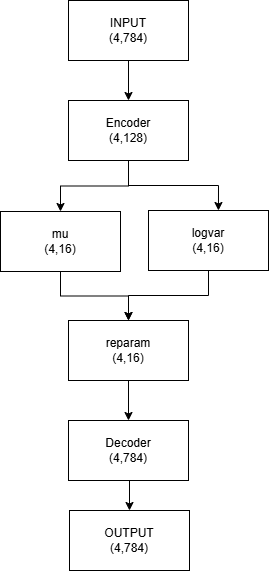

In [18]:
import torch
import torch.nn as nn 
import torch.nn.functional as F
class VAE(nn.Module):
    def __init__(self,in_dim=784,hidden=128,latent=16):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(in_dim,hidden),nn.ReLU(),
            nn.Linear(hidden,hidden),nn.ReLU()
        )
        self.mu = nn.Linear(hidden,latent)
        self.logvar = nn.Linear(hidden,latent)
        self.dec = nn.Sequential(
            nn.Linear(latent,hidden),nn.ReLU(),
            nn.Linear(hidden,hidden),nn.ReLU(),
            nn.Linear(hidden,in_dim),nn.Sigmoid()
        )
    def reparam(self,mu,logvar):
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)
    def forward(self,x):
        h = self.enc(x)
        mu = self.mu(h)
        logvar = self.logvar(h)
        z = self.reparam(mu,logvar)
        return self.dec(z),mu,logvar
model = VAE()
model.eval()
with torch.no_grad():
    recon,mu,logvar = model(torch.randn(4,784))
    print(recon.shape,mu.shape,logvar.shape)
from PIL import Image
import IPython.display as display
img = Image.open('VAE.png')
display.display(img)  